# 푸리에 시리즈 (Fourier Series)

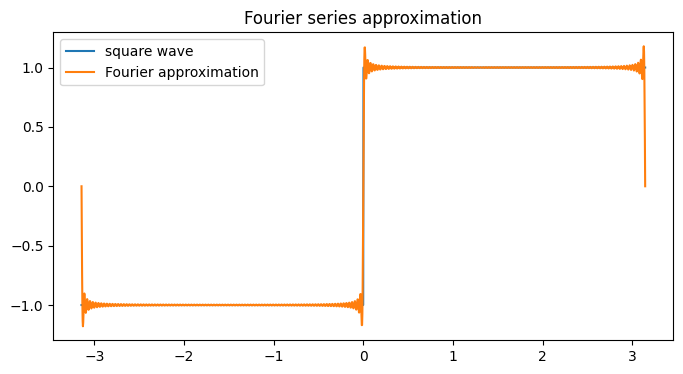

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 2000)

square = np.sign(np.sin(x))

N = 100

approx = np.zeros_like(x)

for k in range(1, N+1):
    n = 2*k - 1
    approx += np.sin(n*x)/n

approx_origin = approx
approx = (4/np.pi)*approx

plt.figure(figsize=(8,4))
plt.plot(x, square, label="square wave")
plt.plot(x, approx, label="Fourier approximation")
# plt.plot(x, approx_origin, label="Approx origin")
plt.legend()
plt.title("Fourier series approximation")
plt.show()

# 푸리에 트랜스폼 (Fourier Transform)

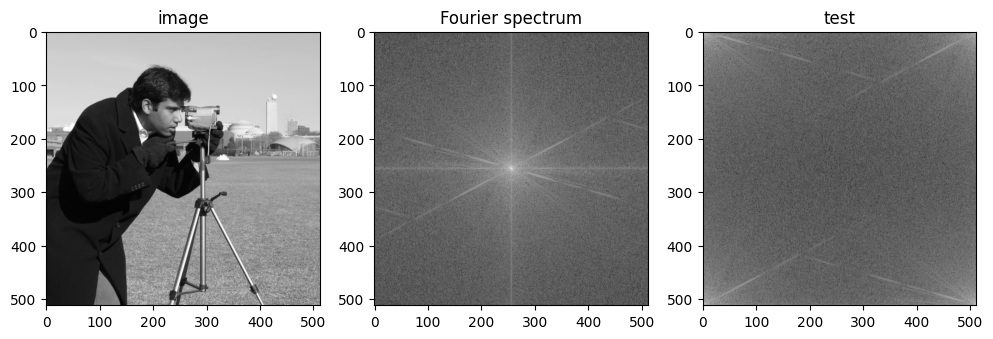

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2, fftshift

img = data.camera()

fft2_img = fft2(img)
F = fftshift(fft2_img)

spectrum = np.log(np.abs(F)+1)
spectrum_fft2 = np.log(np.abs(fft2_img)+1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("image")

plt.subplot(1,3,2)
plt.imshow(spectrum, cmap='gray')
plt.title("Fourier spectrum")

plt.subplot(1,3,3)
plt.imshow(spectrum_fft2, cmap='gray')
plt.title("test")

plt.show()

# 디퓨전 (Diffusion)

[[ 0  0  0 ...  0  0  0]
 [ 1  1  1 ...  1  1  1]
 [ 2  2  2 ...  2  2  2]
 ...
 [61 61 61 ... 61 61 61]
 [62 62 62 ... 62 62 62]
 [63 63 63 ... 63 63 63]]
[[ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 ...
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]
 [ 0  1  2 ... 61 62 63]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


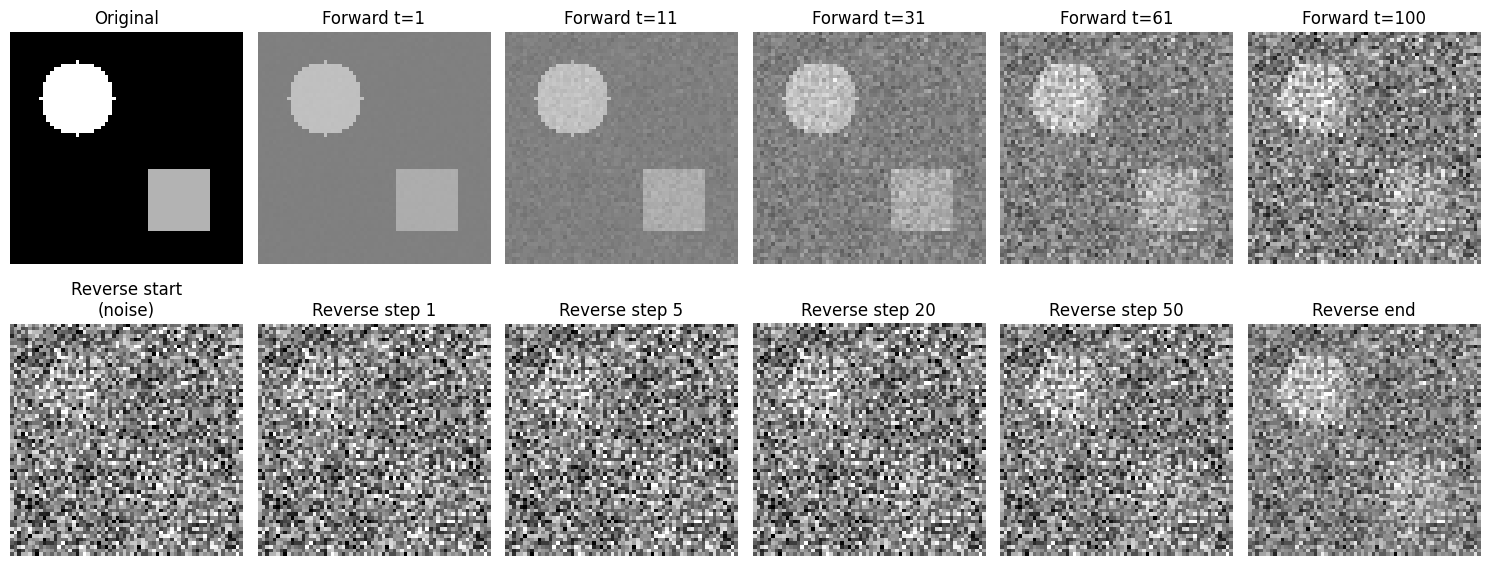

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) 간단한 원본 이미지 만들기
# -----------------------------
H, W = 64, 64
x0 = np.zeros((H, W), dtype=np.float32)

yy, xx = np.mgrid[0:H, 0:W]

print(yy)
print(xx)

circle = (xx - 18)**2 + (yy - 18)**2 <= 10**2
print(circle)
square = (xx >= 38) & (xx <= 54) & (yy >= 38) & (yy <= 54)

x0[circle] = 1.0
x0[square] = 0.7

# -----------------------------
# 2) diffusion schedule
# -----------------------------
T = 200
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

# -----------------------------
# 3) forward diffusion
#    같은 epsilon 하나를 계속 사용
#    x_t = sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) epsilon
# -----------------------------
epsilon = np.random.randn(H, W).astype(np.float32)

x_forward = []
for t in range(T):
    xt = np.sqrt(alpha_bars[t]) * x0 + np.sqrt(1.0 - alpha_bars[t]) * epsilon
    x_forward.append(xt)

xT = x_forward[-1].copy()

# -----------------------------
# 4) reverse diffusion (deterministic)
#    "정답 epsilon"을 알고 있다고 가정
#    추가 noise를 넣지 않음
# -----------------------------
x_reverse = [xT.copy()]
x = xT.copy()

for t in reversed(range(1, T)):
    ab_t = alpha_bars[t]
    ab_prev = alpha_bars[t - 1]

    # 현재 x_t에서 x0 복원
    x0_hat = (x - np.sqrt(1.0 - ab_t) * epsilon) / np.sqrt(ab_t)

    # 다음 단계 x_{t-1} 계산
    x = np.sqrt(ab_prev) * x0_hat + np.sqrt(1.0 - ab_prev) * epsilon
    x_reverse.append(x.copy())

# 마지막으로 t=0에서 x0 복원
x0_recon = (x - np.sqrt(1.0 - alpha_bars[0]) * epsilon) / np.sqrt(alpha_bars[0])
x_reverse.append(x0_recon.copy())

# reverse 리스트를 보기 쉽게 뒤집기
# x_reverse[0] = xT, 마지막 = 복원 이미지
# 그대로 써도 되고, 아래처럼 선택해서 표시해도 됨

# -----------------------------
# 5) 시각화
# -----------------------------
forward_steps = [0, 10, 30, 60, 99]
reverse_indices = [0, 1, 5, 20, 50, 100]  # x_reverse 기준

plt.figure(figsize=(15, 6))

# 원본
plt.subplot(2, 6, 1)
plt.imshow(x0, cmap='gray', vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

# forward
for i, t in enumerate(forward_steps, start=2):
    plt.subplot(2, 6, i)
    plt.imshow(x_forward[t], cmap='gray', vmin=-2, vmax=2)
    plt.title(f"Forward t={t+1}")
    plt.axis("off")

# reverse
for i, k in enumerate(reverse_indices, start=7):
    plt.subplot(2, 6, i)
    plt.imshow(x_reverse[k], cmap='gray', vmin=-2, vmax=2)
    if k == 0:
        plt.title("Reverse start\n(noise)")
    elif k == 100:
        plt.title("Reverse end")
    else:
        plt.title(f"Reverse step {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 과제 (조별미팅까지 준비할 내용)

1. 이 코드를 복사해서 본인의 코드로 저장하고, 각 코드에서 주석 추가해오기
2. 푸리에 시리즈에서 "N", 디퓨전에서 "T" 값조정해보기
3. 푸리에 트랜스폼에서 '본인의 이미지' 업로드 해서 전환해보기